In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms as T
from torchmetrics.classification import MulticlassRecall, MulticlassAccuracy, MulticlassConfusionMatrix

from tqdm import tqdm
from collections import Counter

from Data_Utility.lookup_size import lookup_size_from_excel
from Data_Utility.dataset import PollenFolderWithSizeDataset
from Data_Utility.binary_subset import BinaryPairDataset

from models.basemodel import CNNWithSizeMLP
from models.basemodel_256 import CNN256WithSizeMLP
from models.basemodel_256_multilayer import CNN256WithSizeMLP_multi
from models.convnext_model import ConvNeXtTinyWithSize
from models.specialist_binary import BinarySpecialist
from models.convnext_384 import ConvNeXtTiny384WithSize
from models.convnext_lin import ConvNeXtTinyLinearWithSize

from engine.train_epoch import train_epoch
from engine.train_model import train_model
from engine.eval_epoch import eval_epoch
from engine.plots_loss_accuracy import plot_training_history
from engine.plot_confmat import plot_confusion_matrix, plot_confusion_matrices_horizontal
from engine.data_setup import setup_datasets

from engine.specialist_pair import choose_specialist_pair
from engine.train_specialist import train_binary_specialist
from engine.two_stage_infer import two_stage_predict

from loss_fn.focal_loss import FocalLoss

from engine.random_seed import seed_everything

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
SEED = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)



Using device: cuda


In [34]:

def plot_accuracy_macro_recall_bars(
    accuracies,
    recall_per_class_list,
    model_names=None,
    figsize=(10, 6),
    bar_width=0.36,
    title="Accuracy and Macro Recall by Model",
    title_fontsize=16,
    label_fontsize=14,
    tick_fontsize=12,
    legend_fontsize=12,
    annotate=True,
    save_path=None,
    dpi=300
):
    """
    Plot grouped barplot of accuracy and macro recall for multiple models.

    Parameters
    ----------
    accuracies : list
        Accuracy values for each model, in [0,1] or [0,100].
    recall_per_class_list : list
        Each element can be a torch tensor, numpy array, or list of per-class recalls.
        Macro recall is computed as the mean of recall_per_class.
    model_names : list[str], optional
        Labels on x-axis. If None, uses M0, M1, M2, ...
    """

    # Convert accuracies safely
    acc_values = []
    for acc in accuracies:
        if isinstance(acc, torch.Tensor):
            acc = acc.detach().cpu().item()
        acc_values.append(float(acc))
    accuracies = np.array(acc_values, dtype=float)

    if len(accuracies) != len(recall_per_class_list):
        raise ValueError("accuracies and recall_per_class_list must have the same length.")

    n_models = len(accuracies)

    if model_names is None:
        model_names = [f"M{i}" for i in range(n_models)]

    if len(model_names) != n_models:
        raise ValueError("model_names must have the same length as accuracies.")

    # Convert accuracy to percent if needed
    if np.nanmax(accuracies) <= 1.0:
        accuracies_pct = accuracies * 100
    else:
        accuracies_pct = accuracies.copy()

    # Compute macro recall
    macro_recalls_pct = []
    for recalls in recall_per_class_list:
        if isinstance(recalls, torch.Tensor):
            recalls = recalls.detach().cpu().numpy()
        else:
            recalls = np.asarray(recalls, dtype=float)

        macro_recall = np.nanmean(recalls)

        if np.nanmax(recalls) <= 1.0:
            macro_recall *= 100

        macro_recalls_pct.append(macro_recall)

    macro_recalls_pct = np.array(macro_recalls_pct, dtype=float)

    x = np.arange(n_models)

    fig, ax = plt.subplots(figsize=figsize)

    bars_acc = ax.bar(x - bar_width / 2, accuracies_pct, width=bar_width, label="Accuracy")
    bars_rec = ax.bar(x + bar_width / 2, macro_recalls_pct, width=bar_width, label="Macro recall")

    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xlabel("Model", fontsize=label_fontsize)
    ax.set_ylabel("Value (%)", fontsize=label_fontsize)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=tick_fontsize)
    ax.tick_params(axis="y", labelsize=tick_fontsize)
    ax.set_ylim(min(accuracies)*100-10, 100)
    ax.legend(fontsize=legend_fontsize)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

    if annotate:
        for bars in [bars_acc, bars_rec]:
            for bar in bars:
                h = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + 1.0,
                    f"{h:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=max(9, tick_fontsize - 1)
                )

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

In [49]:


def plot_selected_species_recalls(
    recall_per_class_list,
    class_names,
    selected_species,
    model_names=None,
    figsize=(11, 6),
    title="Recall by Species for Selected Models",
    title_fontsize=16,
    label_fontsize=14,
    tick_fontsize=12,
    legend_fontsize=11,
    bar_width=0.18,
    annotate=True,
    save_path=None,
    dpi=300
):
    """
    Plot recall for selected species across multiple models.

    Parameters
    ----------
    recall_per_class_list : list
        List of per-class recall arrays/tensors, one for each model.
    class_names : list[str]
        Class names in the same order as recall_per_class.
    selected_species : list[str]
        Species to plot.
    model_names : list[str], optional
        Names of models on x-axis. If None, uses M0, M1, M2, ...
    """

    n_models = len(recall_per_class_list)

    if model_names is None:
        model_names = [f"M{i}" for i in range(n_models)]

    if len(model_names) != n_models:
        raise ValueError("model_names must have same length as recall_per_class_list.")

    class_to_idx = {name: i for i, name in enumerate(class_names)}

    for sp in selected_species:
        if sp not in class_to_idx:
            raise ValueError(f"Species {sp!r} not found in class_names.")

    # Convert recalls into percentage values for the selected species
    selected_recalls = {sp: [] for sp in selected_species}

    for recalls in recall_per_class_list:
        if isinstance(recalls, torch.Tensor):
            recalls = recalls.detach().cpu().numpy()
        else:
            recalls = np.asarray(recalls, dtype=float)

        for sp in selected_species:
            val = recalls[class_to_idx[sp]]
            if val <= 1.0:
                val *= 100
            selected_recalls[sp].append(val)

    x = np.arange(n_models)
    n_species = len(selected_species)

    fig, ax = plt.subplots(figsize=figsize)

    offsets = (np.arange(n_species) - (n_species - 1) / 2) * bar_width

    for i, sp in enumerate(selected_species):
        bars = ax.bar(
            x + offsets[i],
            selected_recalls[sp],
            width=bar_width,
            label=sp
        )

        if annotate:
            for bar in bars:
                h = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + 1.0,
                    f"{h:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=max(9, tick_fontsize - 2)
                )

    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xlabel("Model", fontsize=label_fontsize)
    ax.set_ylabel("Recall (%)", fontsize=label_fontsize)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=tick_fontsize)
    ax.tick_params(axis="y", labelsize=tick_fontsize)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=legend_fontsize)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

In [53]:
selected_species = [
    "Bellis perennis",
    "Hypochaeris radicata",
    "Crepis capillaris",
]

# Baseline model and preprocessing effects

In [19]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=False
    ,val_bool=False
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 7922 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: False
bootstrap_impute_bool: False
Total scanned images: 8078
   Final dataset size:   7922
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 
Dropped missing:      156


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 7922
Dataset setup complete.


In [5]:
seed_everything(SEED, deterministic=True)

model_base = CNNWithSizeMLP(num_classes=num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base.parameters(), lr=0.001)

## M0 Baseline (Erik)


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 7.536622047424316
Mean of batch means: 0.8102777014013196
Mean of batch stds: 0.9024200390596859

Test Accuracy: 0.7680
Test Recall per class:
Class 0 (Bellis perennis): 0.3521
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9781
Class 3 (Cichorium intybus): 0.9846
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9450
Class 6 (Hypochaeris radicata): 0.5050
Class 7 (Sonchus arvensis): 0.9162
Class 8 (Tragopogon pratensis): 0.9458
Class 9 (Tussilago farfara): 0.9940


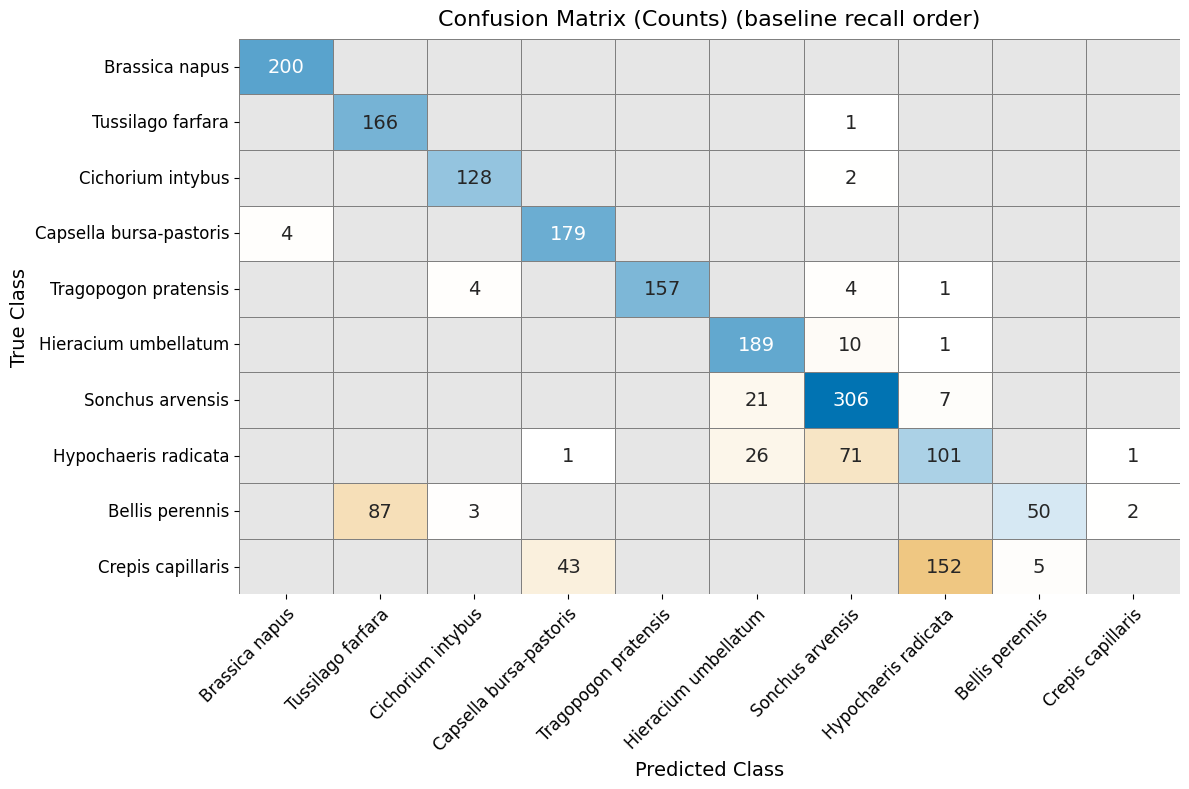

In [6]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class_M0, accuracy_M0, probs_base,y_base, conf_base = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M0:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M0):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_base, idx_to_class, normalize=False, save_path="figures/confmat_base", sort_by_recall_desc=True)

## M1 Mean imputation + val


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.26844596862793
Mean of batch means: 0.8152145166866115
Mean of batch stds: 0.9938946258826334

Test Accuracy: 0.7627
Test Recall per class:
Class 0 (Bellis perennis): 0.6972
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9891
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9750
Class 6 (Hypochaeris radicata): 0.5900
Class 7 (Sonchus arvensis): 0.6647
Class 8 (Tragopogon pratensis): 0.9277
Class 9 (Tussilago farfara): 1.0000


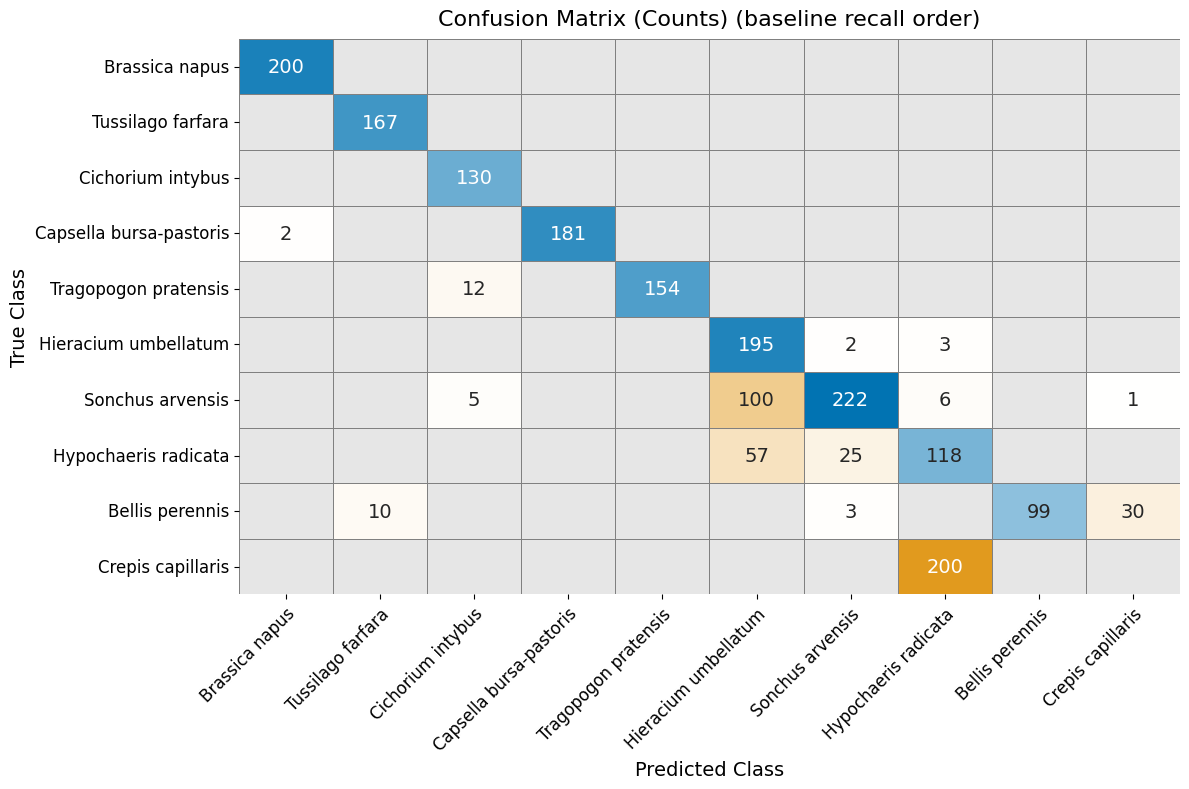

In [7]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_fill_val.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class_M1, accuracy_M1, probs_M1, y_M1, conf_M1 = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M1:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M1):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M1, idx_to_class, normalize=False, save_path="figures/confmat_M1")

## M2 Mean imputation + val + aug


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 7.86814022064209
Mean of batch means: 0.8290309945090872
Mean of batch stds: 0.9259786058644779

Test Accuracy: 0.7648
Test Recall per class:
Class 0 (Bellis perennis): 0.8803
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9550
Class 6 (Hypochaeris radicata): 0.6700
Class 7 (Sonchus arvensis): 0.5689
Class 8 (Tragopogon pratensis): 0.9036
Class 9 (Tussilago farfara): 1.0000


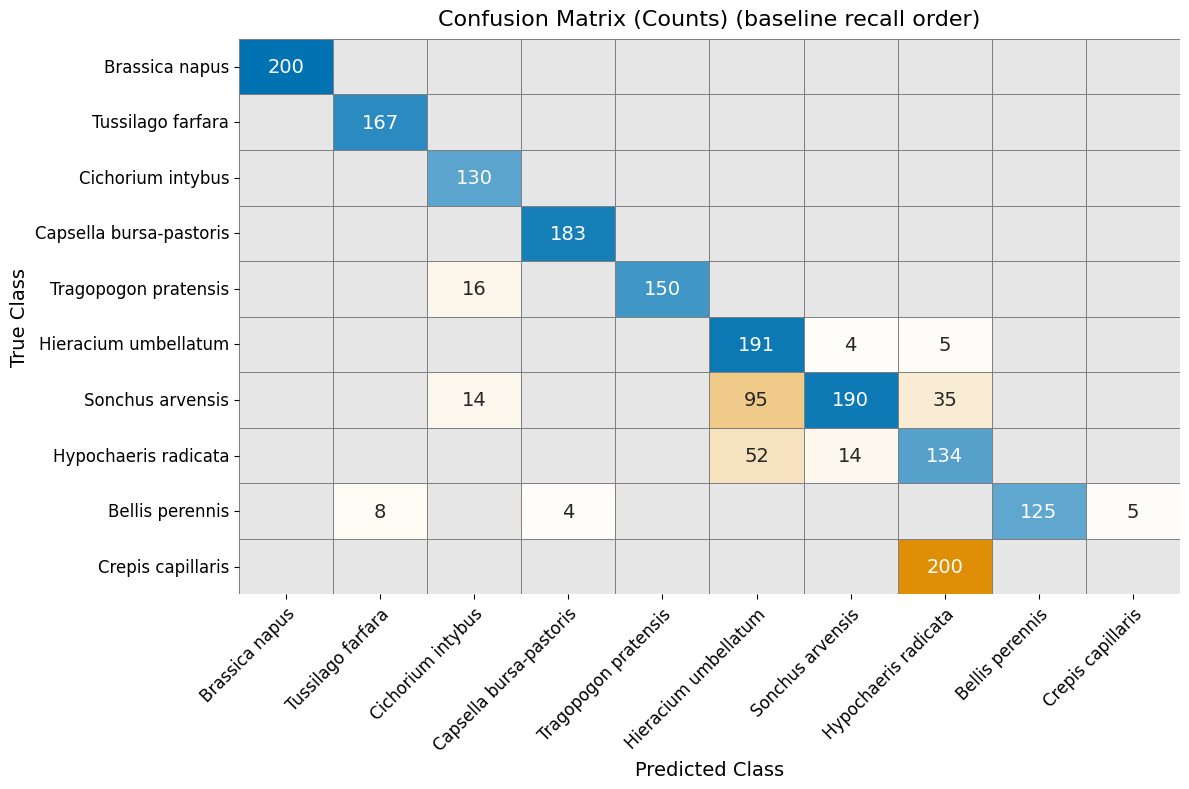

In [8]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_fill_val_aug.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class_M2, accuracy_M2, probs_M2, y_M2, conf_M2 = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M2:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M2):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M2, idx_to_class, normalize=False,save_path="figures/confmat_M2")

## M3 Mean imputation + val + aug (1000)


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 9.392691612243652
Mean of batch means: 0.6829970625580334
Mean of batch stds: 0.7712958640739566

Test Accuracy: 0.7341
Test Recall per class:
Class 0 (Bellis perennis): 0.0493
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9945
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.1300
Class 5 (Hieracium umbellatum): 0.9550
Class 6 (Hypochaeris radicata): 0.4300
Class 7 (Sonchus arvensis): 0.7814
Class 8 (Tragopogon pratensis): 0.9699
Class 9 (Tussilago farfara): 1.0000


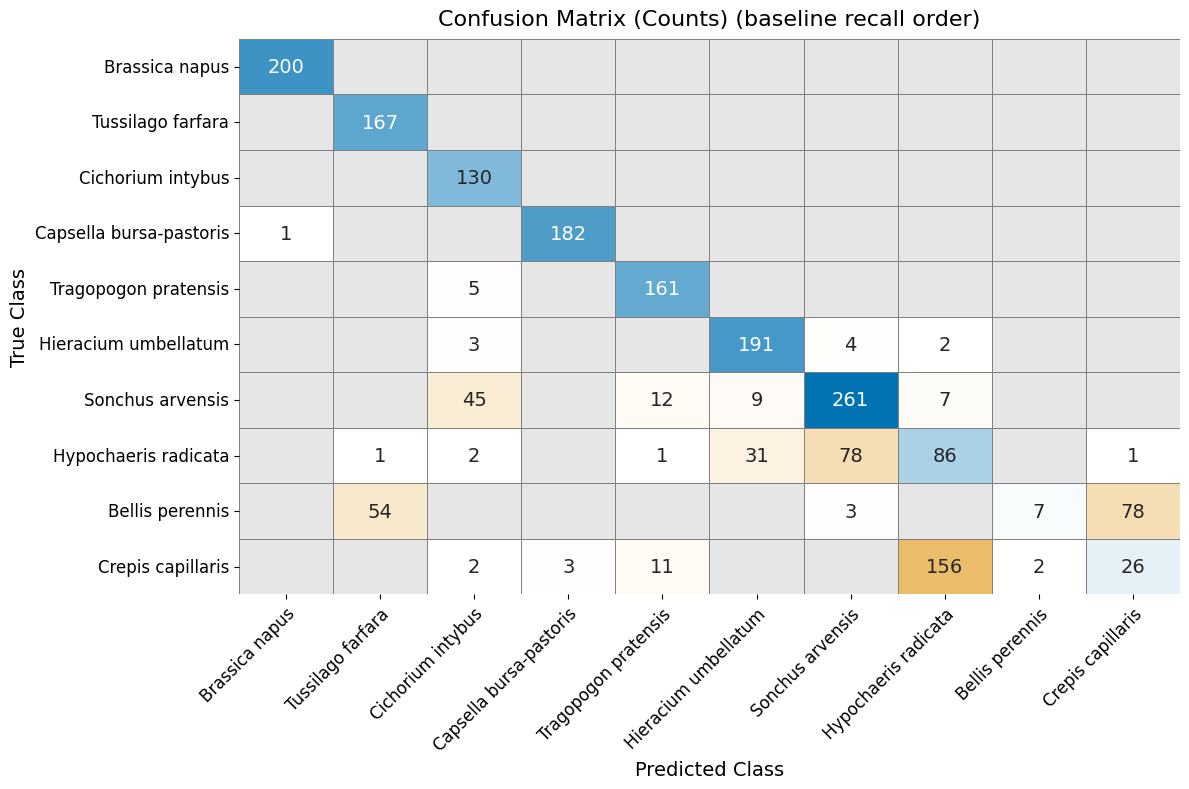

In [9]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_models/aug1000_model.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class_M3, accuracy_M3, probs_M3, y_M3, conf_M3 = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M3:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M3):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M3, idx_to_class, normalize=False,save_path="figures/confmat_M3")

## M4 Bootstrap imputation + val + aug


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 11.596412658691406
Mean of batch means: 0.8890369172956123
Mean of batch stds: 1.038719575913226

Test Accuracy: 0.7721
Test Recall per class:
Class 0 (Bellis perennis): 0.9577
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9650
Class 6 (Hypochaeris radicata): 0.2600
Class 7 (Sonchus arvensis): 0.9042
Class 8 (Tragopogon pratensis): 0.7289
Class 9 (Tussilago farfara): 1.0000


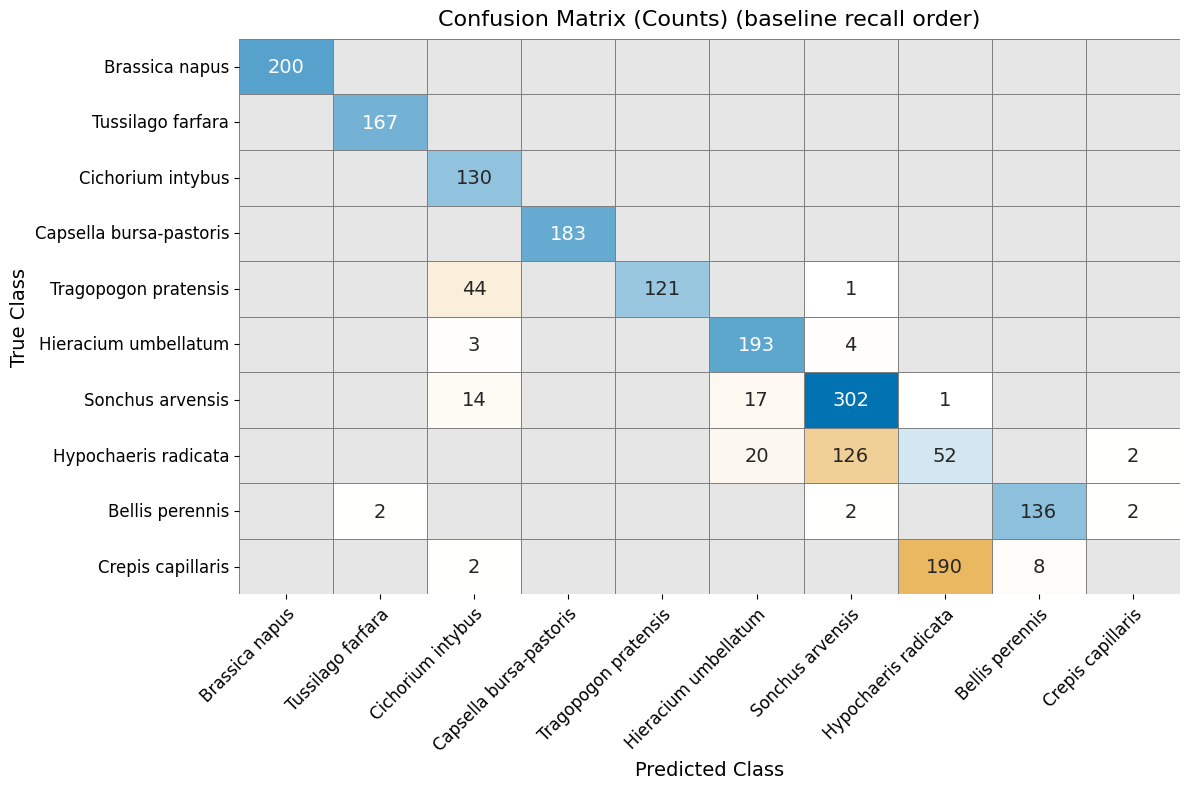

In [ ]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_val_aug_boot.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class_M4, accuracy_M4, probs_M4, y_M4, conf_M4 = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M4:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M4, idx_to_class, normalize=False,save_path="figures/confmat_M4")

## M5 Bootstrap imputation + val + aug + ratio

In [14]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=False
    ,val_bool=False
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
    ,quota_bool=True
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 7922 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: False
bootstrap_impute_bool: False
Total scanned images: 8078
   Final dataset size:   7922
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 
Dropped missing:      156


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 7922
Dataset setup complete.


In [16]:
seed_everything(SEED, deterministic=True)

model_base = CNNWithSizeMLP(num_classes=num_classes,size_dim=3).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base.parameters(), lr=0.001)


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.097198486328125
Mean of batch means: 0.8573949346776868
Mean of batch stds: 0.9699667135223013

Test Accuracy: 0.7617
Test Recall per class:
Class 0 (Bellis perennis): 0.6056
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.5519
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0050
Class 5 (Hieracium umbellatum): 0.9650
Class 6 (Hypochaeris radicata): 0.7400
Class 7 (Sonchus arvensis): 0.8263
Class 8 (Tragopogon pratensis): 0.9819
Class 9 (Tussilago farfara): 0.9940


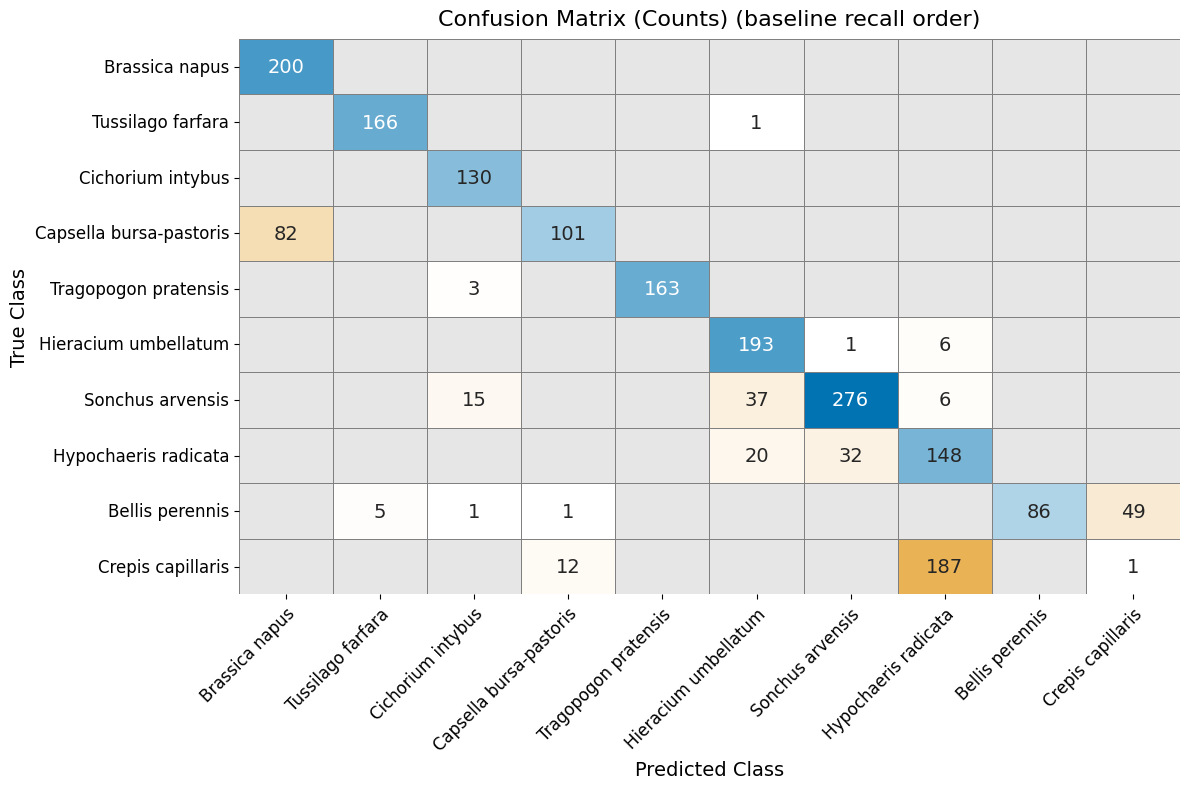

In [17]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_val_aug_boot_quota.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class_M5, accuracy_M5, probs_M5, y_M5, conf_M5 = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M5:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M5):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M5, idx_to_class, normalize=False,save_path="figures/confmat_M5")

## Result plot for baselinemodel

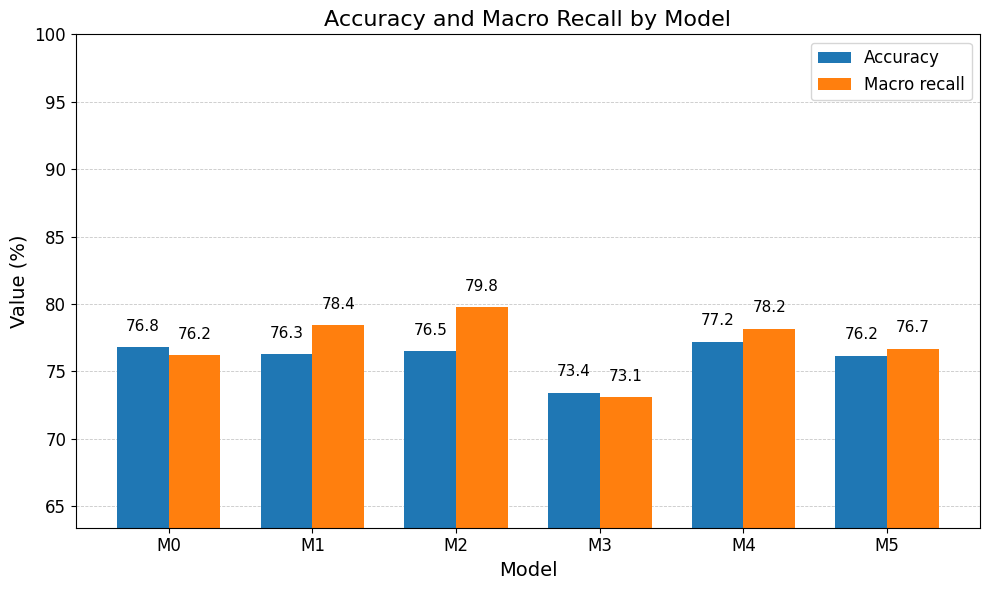

In [59]:
plot_accuracy_macro_recall_bars(
    accuracies=[accuracy_M0, accuracy_M1, accuracy_M2, accuracy_M3, accuracy_M4, accuracy_M5],
    recall_per_class_list=[recall_per_class_M0, recall_per_class_M1, recall_per_class_M2, recall_per_class_M3, recall_per_class_M4, recall_per_class_M5],
    model_names=["M0", "M1", "M2", "M3", "M4", "M5"],
    save_path="figures/accuracy_macro_recall_basemodels.pdf"
)

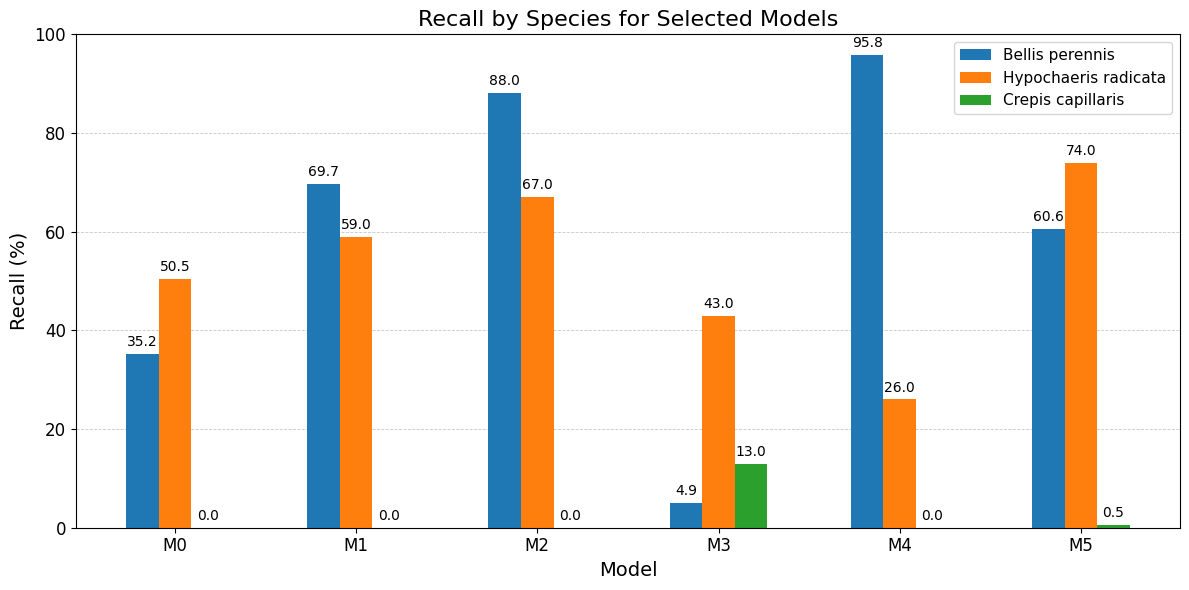

In [60]:
plot_selected_species_recalls(
    recall_per_class_list=[recall_per_class_M0, recall_per_class_M1, recall_per_class_M2, recall_per_class_M3, recall_per_class_M4, recall_per_class_M5],
    class_names=classes,
    selected_species=selected_species,
    model_names=["M0", "M1", "M2", "M3", "M4", "M5"],
    figsize=(12, 6),
    save_path="figures/selected_species_recalls_basemodels.pdf"
)

# Reducing the image representation to 256 dimensions

In [61]:
seed_everything(SEED, deterministic=True)
model_base256 = CNN256WithSizeMLP(num_classes=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)

# M6 256-dim + mean imputation + val


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.504186630249023
Mean of batch means: 0.753193600255935
Mean of batch stds: 0.9894544765597484

Test Accuracy: 0.8371
Test Recall per class:
Class 0 (Bellis perennis): 0.8521
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9781
Class 3 (Cichorium intybus): 0.9923
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9150
Class 6 (Hypochaeris radicata): 0.9150
Class 7 (Sonchus arvensis): 0.8533
Class 8 (Tragopogon pratensis): 0.9759
Class 9 (Tussilago farfara): 1.0000


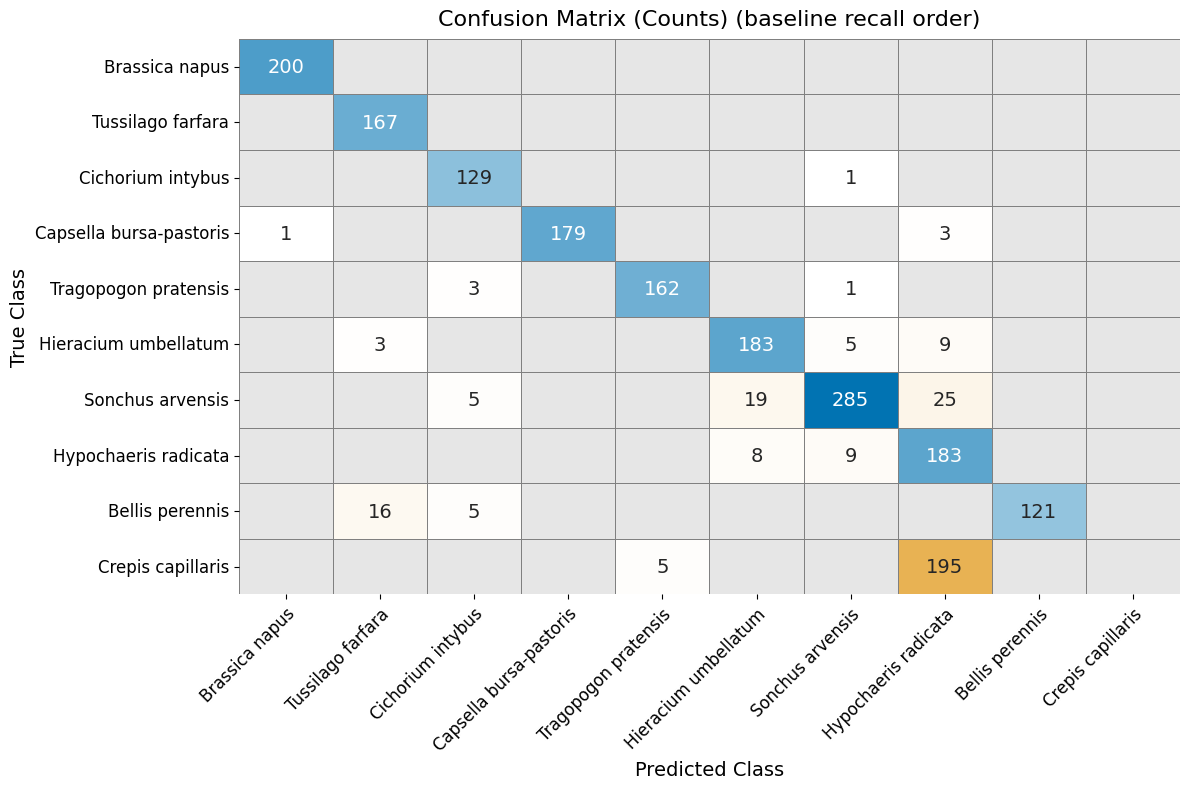

In [21]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_fill_val.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class_M6, accuracy_M6, probs_M6, y_M6, conf_M6 = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M6:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M6):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M6, idx_to_class, normalize=False, save_path="figures/confmat_M6")

## M7 256-dim + bootstrap imputation + val


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 10.501511573791504
Mean of batch means: 0.7974957784668344
Mean of batch stds: 1.0212229842045268

Test Accuracy: 0.7503
Test Recall per class:
Class 0 (Bellis perennis): 0.9296
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9727
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9500
Class 6 (Hypochaeris radicata): 0.2500
Class 7 (Sonchus arvensis): 0.6916
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 0.9940


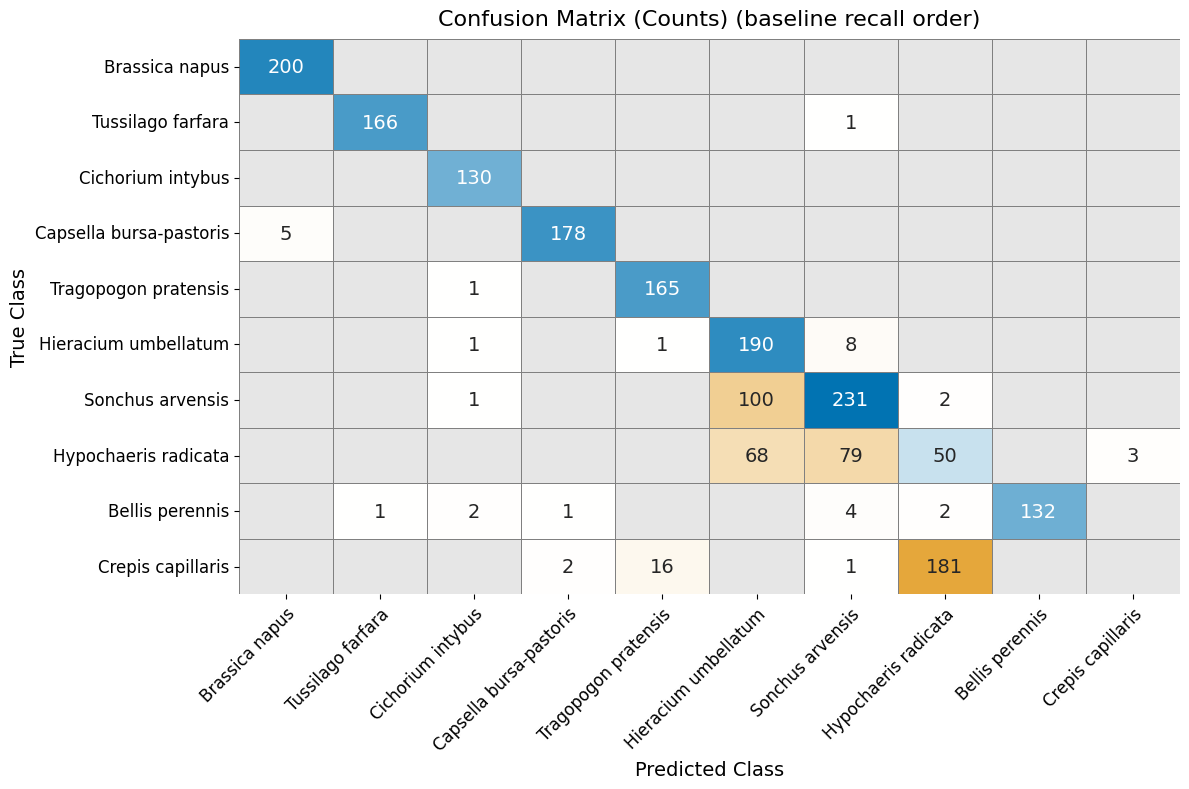

In [22]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_fill_val_boot.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class_M7, accuracy_M7, probs_M7, ys_M7, conf_M7 = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M7:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M7):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M7, idx_to_class, normalize=False)

## M8 256-dim + mean imputation + val + aug


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.317948341369629
Mean of batch means: 0.7193891332774865
Mean of batch stds: 0.8810300983366419

Test Accuracy: 0.8319
Test Recall per class:
Class 0 (Bellis perennis): 0.9507
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0950
Class 5 (Hieracium umbellatum): 0.9600
Class 6 (Hypochaeris radicata): 0.5700
Class 7 (Sonchus arvensis): 0.8772
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


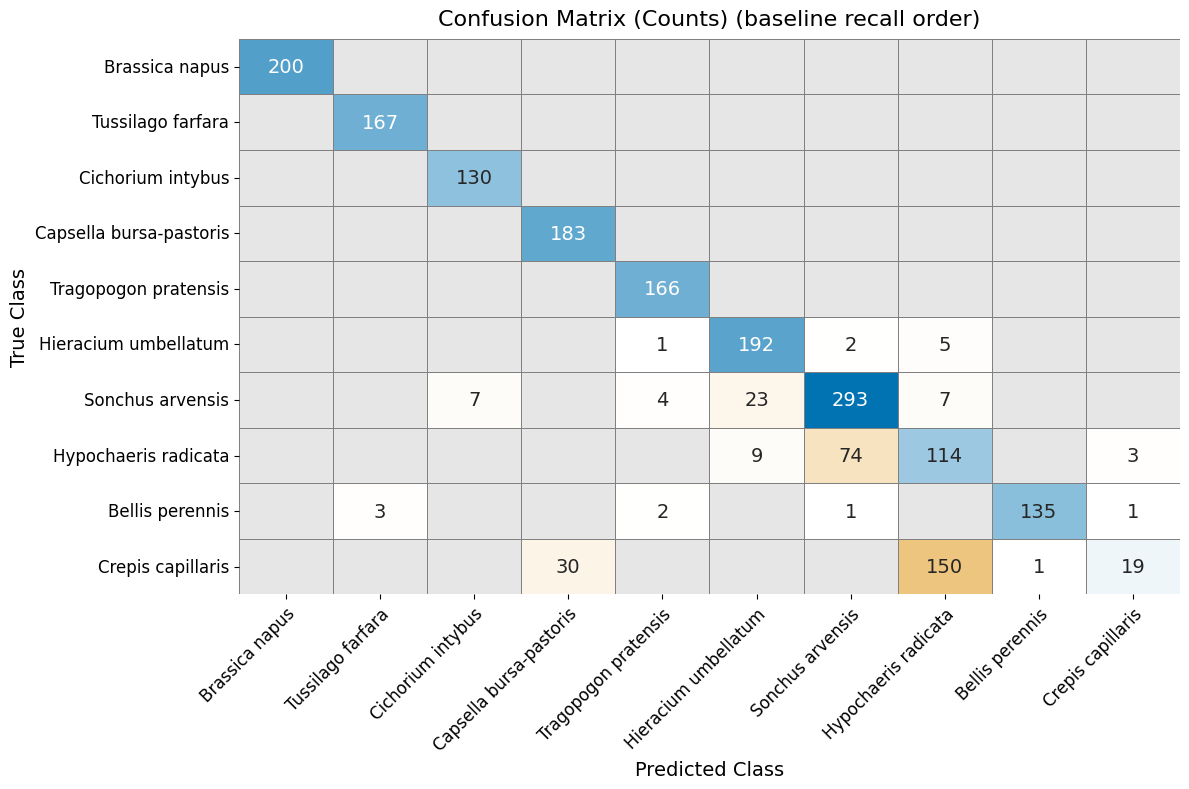

In [23]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_fill_val_aug.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class_M8, accuracy_M8, probs_M8, y_M8, conf_M8 = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M8:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M8):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M8, idx_to_class, normalize=False, save_path="figures/confmat_M8")

## M9 256-dim + mean imputation + focal (γ = 1) + aug

In [25]:
seed_everything(SEED, deterministic=True)
model_base256 = CNN256WithSizeMLP(num_classes=10).to(device)
loss_fn = FocalLoss(gamma=1.0)
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.725157737731934
Mean of batch means: 0.7143316640228522
Mean of batch stds: 0.8647256386084635

Test Accuracy: 0.8132
Test Recall per class:
Class 0 (Bellis perennis): 0.9437
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 0.9769
Class 4 (Crepis capillaris): 0.0550
Class 5 (Hieracium umbellatum): 0.9400
Class 6 (Hypochaeris radicata): 0.4300
Class 7 (Sonchus arvensis): 0.9012
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


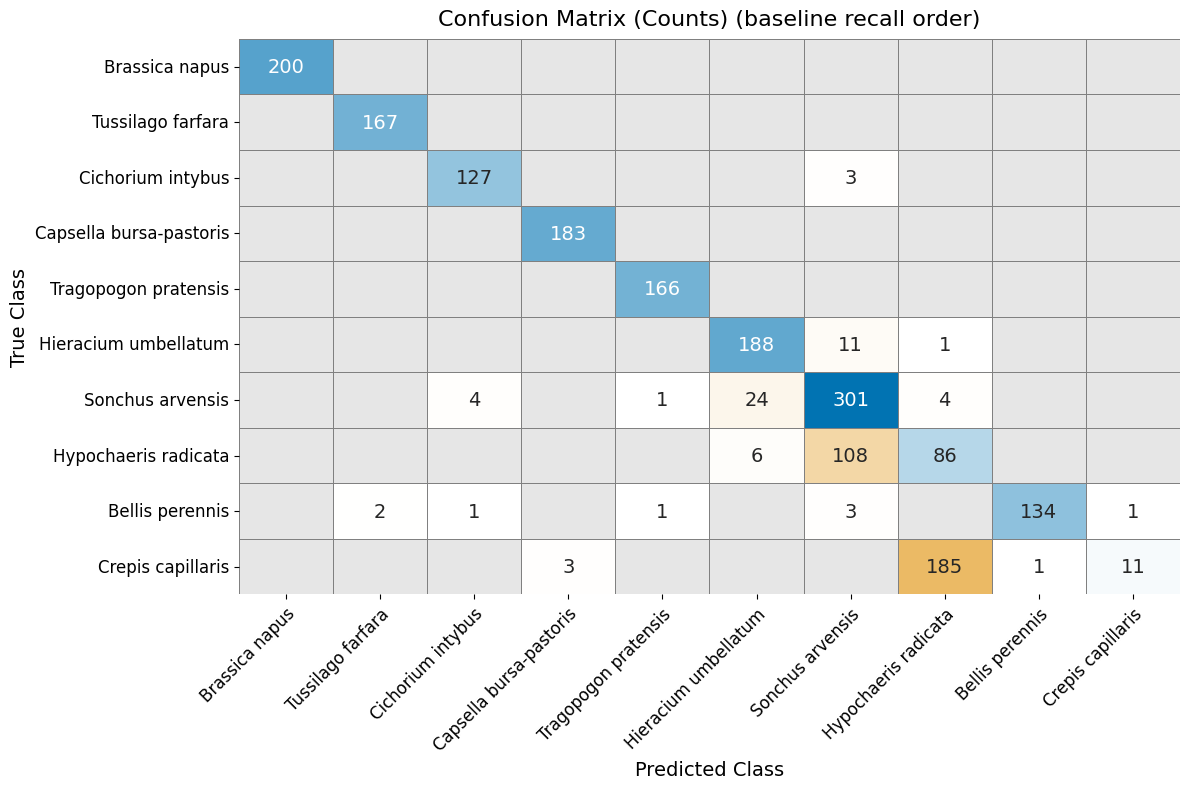

In [43]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_focal_fill_val_aug.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class_M9, accuracy_M9, probs_M9,ys_M9, conf_M9 = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M9:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M9):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M9, idx_to_class, normalize=False, save_path="figures/confmat_M9")

## M10 256-dim + mean imputation + focal (γ = 2) + aug


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.449967384338379
Mean of batch means: 0.7734000731687076
Mean of batch stds: 0.915556755222258

Test Accuracy: 0.7898
Test Recall per class:
Class 0 (Bellis perennis): 0.7676
Class 1 (Brassica napus): 0.9950
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9650
Class 6 (Hypochaeris radicata): 0.4750
Class 7 (Sonchus arvensis): 0.8263
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


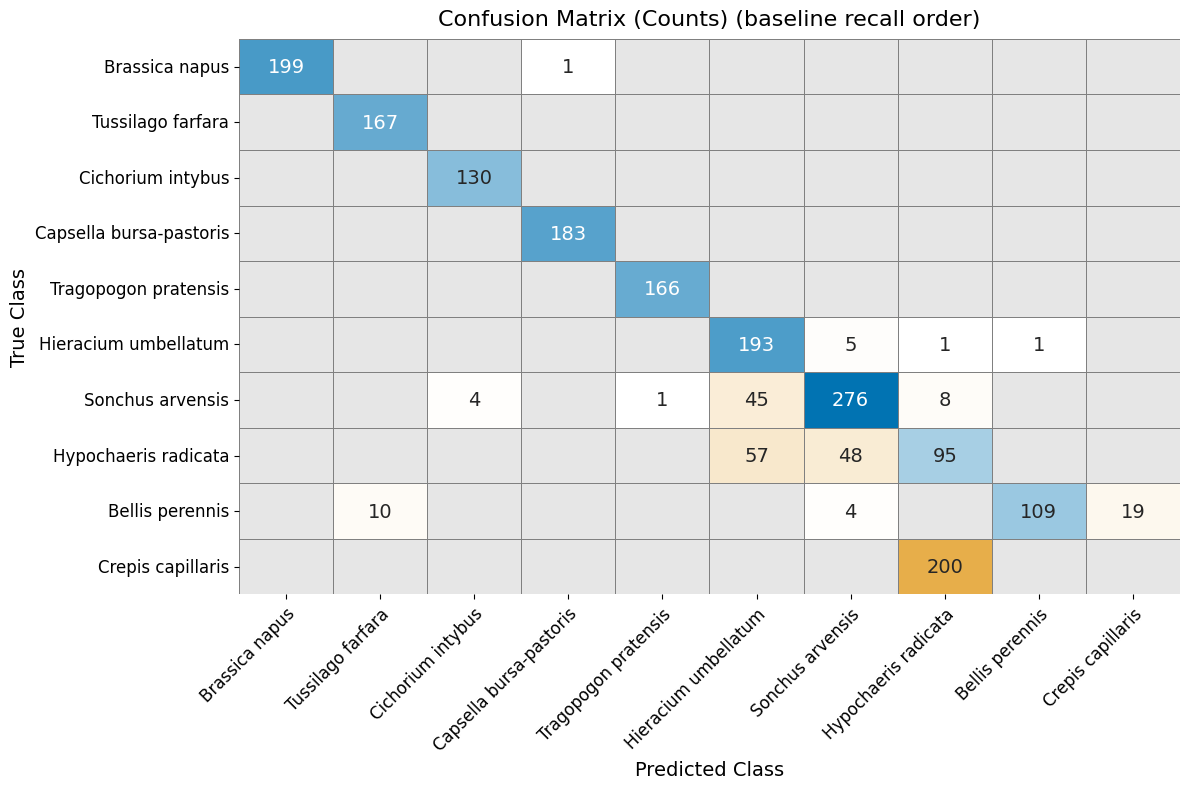

In [44]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_focal2_fill_val_aug.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class_M10, accuracy_M10, probs_M10,ys_M10, conf_M10 = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M10:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M10):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M10, idx_to_class, normalize=False, save_path="figures/confmat_M10")

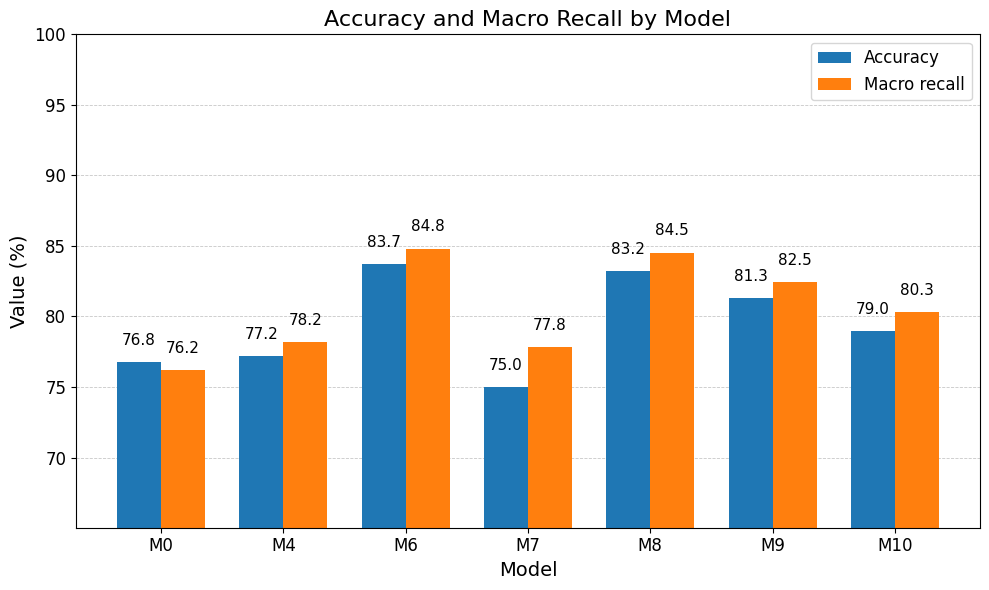

0.7502601742744446


In [55]:
plot_accuracy_macro_recall_bars(
    accuracies=[accuracy_M0,accuracy_M4,accuracy_M6, accuracy_M7, accuracy_M8, accuracy_M9, accuracy_M10],
    recall_per_class_list=[recall_per_class_M0,recall_per_class_M4,recall_per_class_M6, recall_per_class_M7, recall_per_class_M8, recall_per_class_M9, recall_per_class_M10],
    model_names=["M0","M4","M6", "M7", "M8", "M9", "M10"],
    save_path="figures/accuracy_macro_recall_256basemodels.pdf"
)
print(min([accuracy_M6, accuracy_M7, accuracy_M8, accuracy_M9, accuracy_M10]))

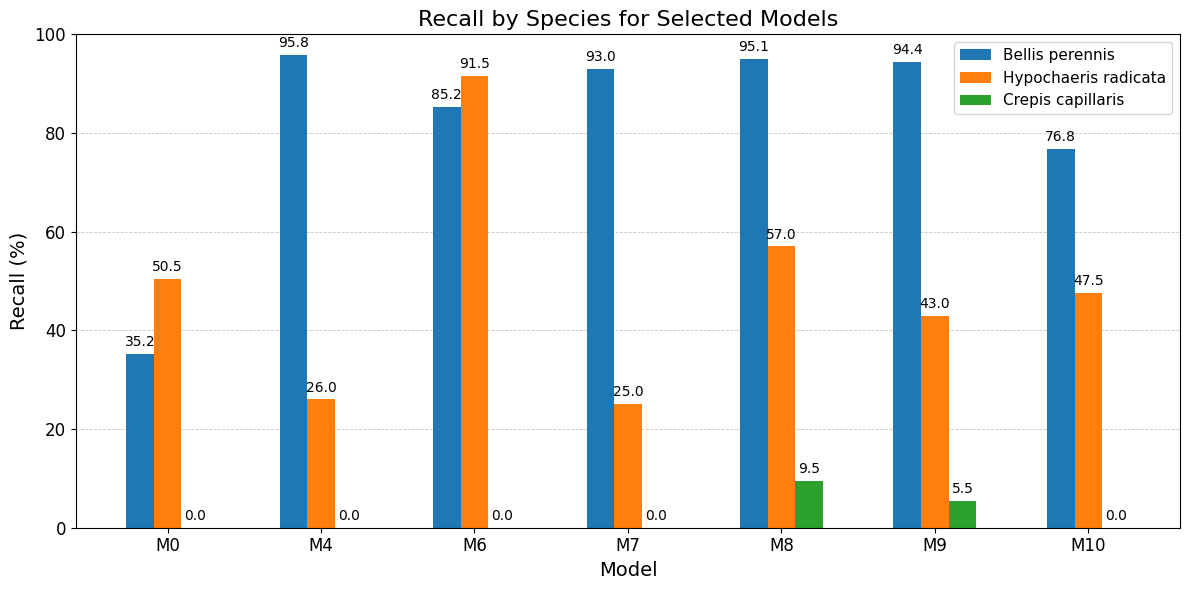

In [62]:
plot_selected_species_recalls(
    recall_per_class_list=[recall_per_class_M0,recall_per_class_M4,recall_per_class_M6, recall_per_class_M7, recall_per_class_M8, recall_per_class_M9, recall_per_class_M10],
    class_names=classes,
    selected_species=selected_species,
    model_names=["M0","M4","M6", "M7", "M8", "M9", "M10"],
    figsize=(12, 6),
    save_path="figures/selected_species_recalls_256basemodels.pdf"
)

# ConvNeXt-Tiny model variants

## M11 ConvNeXt-Tiny + mean imputation + val

In [39]:
seed_everything(SEED, deterministic=True)
model = ConvNeXtTinyWithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)



=== Backbone Feature Inspection ===
Min of mins: -10.834009170532227
Max of maxs: 16.42815589904785
Mean of batch means: 0.018412627378997744
Mean of batch stds: 1.106119463678266

Test Accuracy: 0.7997
Test Recall per class:
Class 0 (Bellis perennis): 0.6620
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0600
Class 5 (Hieracium umbellatum): 0.8650
Class 6 (Hypochaeris radicata): 0.4500
Class 7 (Sonchus arvensis): 0.9671
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


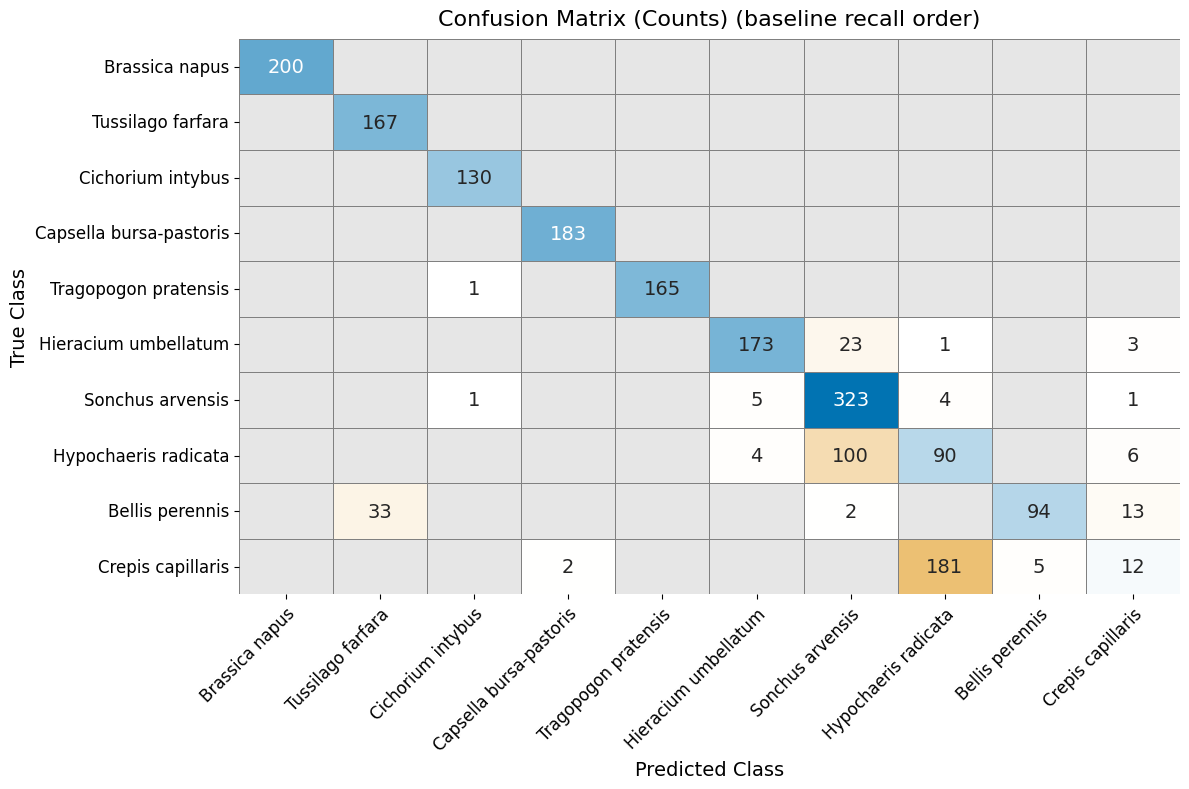

In [45]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/convnext_fill_val.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class_M11, accuracy_M11, probs_M11, ys_M11, conf_M11 = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M11:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M11):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M11, idx_to_class, normalize=False, save_path="figures/confmat_M11")

## M12 ConvNeXt-Tiny + mean imputation + val + aug


=== Backbone Feature Inspection ===
Min of mins: -12.666570663452148
Max of maxs: 14.322230339050293
Mean of batch means: 0.018298786706777793
Mean of batch stds: 1.0869133560383906

Test Accuracy: 0.8517
Test Recall per class:
Class 0 (Bellis perennis): 0.7042
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.3850
Class 5 (Hieracium umbellatum): 0.8500
Class 6 (Hypochaeris radicata): 0.6550
Class 7 (Sonchus arvensis): 0.9371
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


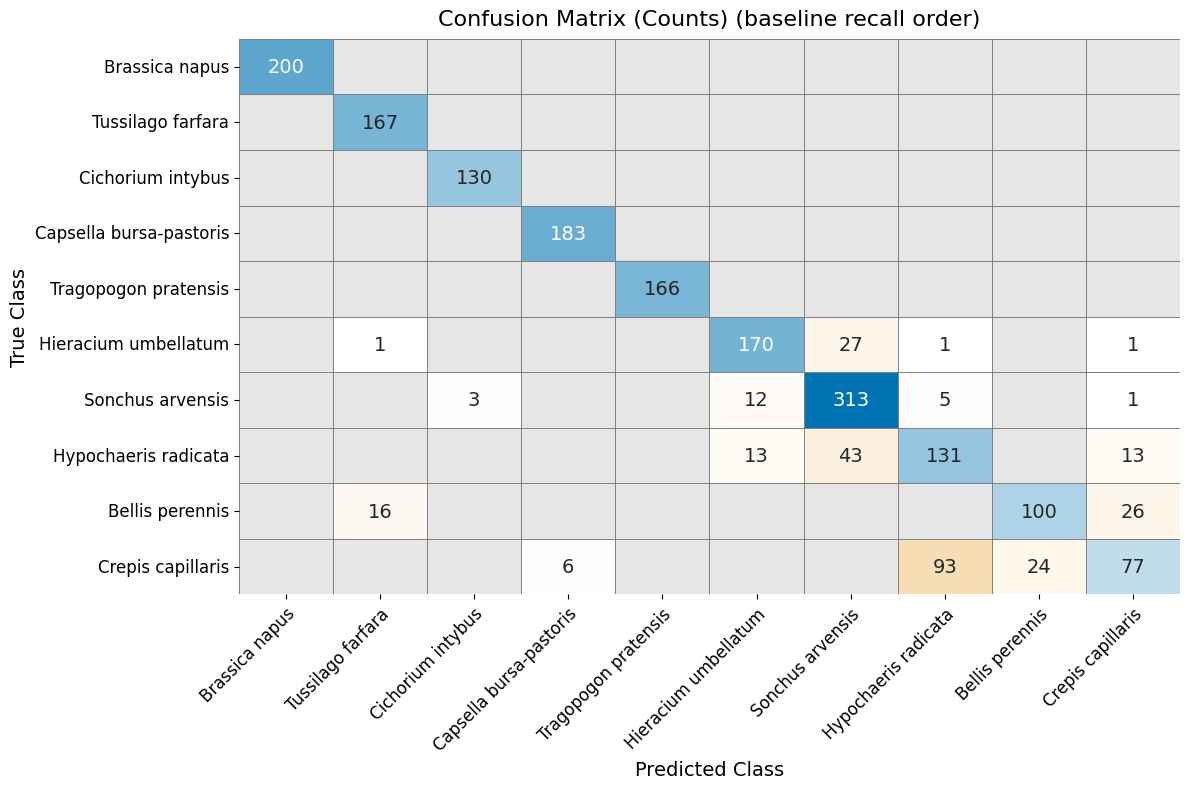

In [47]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_models/convnext_tiny_size_aug.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class_M12, accuracy_M12, probs_M12, y_M12, conf_M12 = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M12:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M12):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

#plot_confusion_matrix(conf, idx_to_class, normalize=False, sort_by_recall_desc=True, figsize=(14,10), annot_size=18, tick_size=16,label_size=18, title_size=20)
plot_confusion_matrix(conf=conf_M12, idx_to_class=idx_to_class, normalize=False, save_path="figures/confmat_M12")

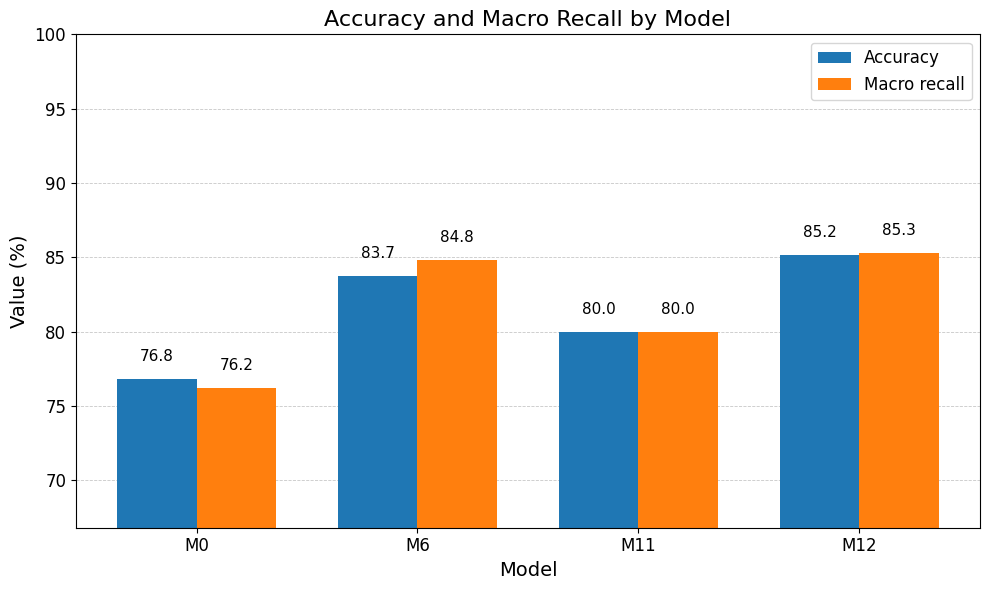

In [48]:
plot_accuracy_macro_recall_bars(
    accuracies=[accuracy_M0, accuracy_M6, accuracy_M11, accuracy_M12],
    recall_per_class_list=[recall_per_class_M0, recall_per_class_M6, recall_per_class_M11, recall_per_class_M12],
    model_names=["M0", "M6", "M11", "M12"],
    save_path="figures/accuracy_macro_recall_convnextmodels.pdf"
)

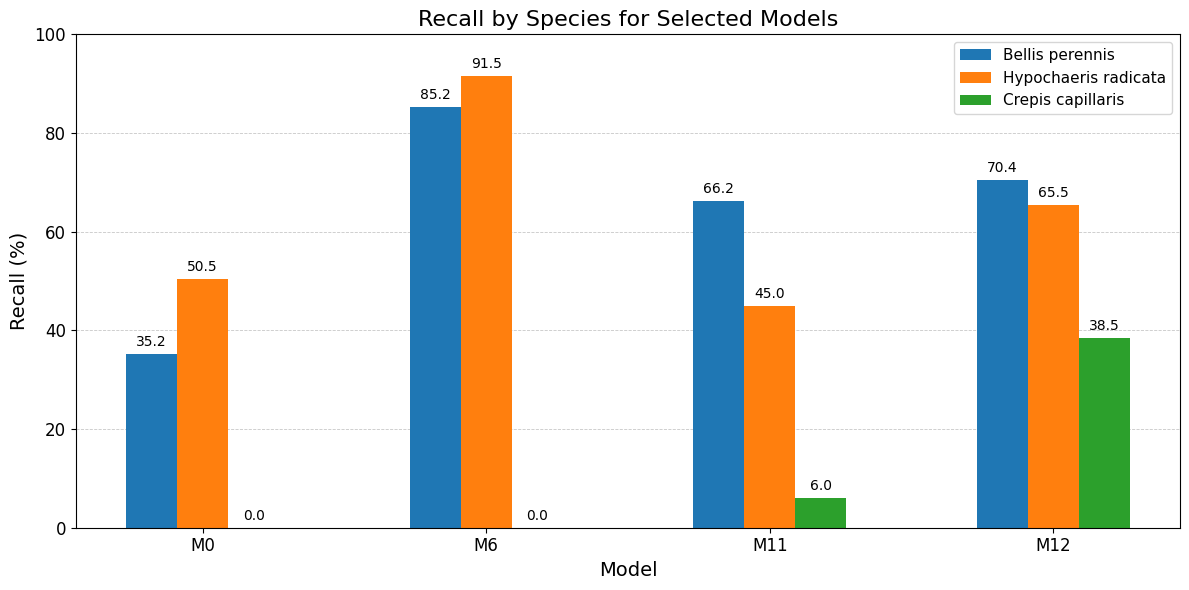

In [63]:
plot_selected_species_recalls(
    recall_per_class_list=[recall_per_class_M0, recall_per_class_M6, recall_per_class_M11, recall_per_class_M12],
    class_names=classes,
    selected_species=selected_species,
    model_names=["M0", "M6", "M11", "M12"],
    figsize=(12, 6),
    save_path="figures/selected_species_recalls_convnextmodels.pdf")